In [109]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import datetime 

df = pd.read_csv('bonds_dashboards/fred_md.csv')
df = df.iloc[1:].reset_index(drop=True)
df['sasdate'] = pd.to_datetime(df['sasdate']).dt.to_period('M')
df = df[[
    'sasdate',
    'FEDFUNDS',   # Current policy rate
    'CPIAUCSL',   # Inflation
    'INDPRO',     # Industrial production
    'UNRATE',     # Unemployment
    'M2SL',       # Money supply
    'S&P 500',    # Equity market
] + ['TB3MS', 'GS1', 'GS5', 'GS10']]
df = df[df['sasdate'] >= pd.Period('1979-1-1', freq='M')]
df


,sasdate,FEDFUNDS,CPIAUCSL,INDPRO,UNRATE,M2SL,S&P 500,TB3MS,GS1,GS5,GS10
240,1979-01,10.07,68.500,51.5250,5.9,1371.6,99.71,9.35,10.41,9.20,9.10
241,1979-02,10.06,69.200,51.7780,5.9,1377.8,98.23,9.32,10.24,9.13,9.10
242,1979-03,10.09,69.900,51.9382,5.8,1387.8,100.10,9.48,10.25,9.20,9.12
243,1979-04,10.01,70.600,51.3251,5.8,1402.1,102.10,9.46,10.12,9.25,9.18
244,1979-05,10.24,71.400,51.7782,5.6,1410.2,99.73,9.61,10.12,9.24,9.25
...,...,...,...,...,...,...,...,...,...,...,...
795,2025-04,4.33,320.321,103.6224,4.2,21805.1,5369.50,4.21,3.95,3.91,4.28
796,2025-05,4.33,320.580,103.6570,4.2,21884.6,5810.92,4.25,4.09,4.02,4.42
797,2025-06,4.33,321.500,104.2115,4.1,22022.1,6029.95,4.23,4.06,3.96,4.38
798,2025-07,4.33,322.132,103.8194,4.2,22115.8,6296.50,4.25,4.08,3.95,4.39


In [111]:
df.isna().sum()

sasdate     0
FEDFUNDS    0
CPIAUCSL    0
INDPRO      0
UNRATE      0
M2SL        0
S&P 500     0
TB3MS       0
GS1         0
GS5         0
GS10        0
dtype: int64

In [171]:
# Select yield columns (adjust names based on your FRED-MD version)
yield_columns = ['TB3MS', 'GS1', 'GS5', 'GS10']
maturities = [0.25, 1, 5, 10]  # in years

# Get the most recent date or a specific date
date = df.index[-1]  # most recent
yields = df.loc[date, yield_columns].values

# Create yield curve plot
plt.figure(figsize=(10, 6))
plt.plot(maturities, yields, marker='o', linewidth=2)
plt.xlabel('Maturity (Years)')
plt.ylabel('Yield (%)')
plt.title(f'Treasury Yield Curve - ') #{date.strftime("%Y-%m-%d")}
plt.grid(True, alpha=0.3)
plt.show()

In [173]:
from scipy.interpolate import interp1d
import numpy as np
# Interpolate
f = interp1d(maturities, yields, kind='cubic')
maturities_smooth = np.linspace(0.25, 10, 100)
yields_smooth = f(maturities_smooth)

plt.plot(maturities_smooth, yields_smooth, linewidth=2)
plt.scatter(maturities, yields, color='red', s=50, zorder=5)

In [175]:
if isinstance(df.index, pd.PeriodIndex):
    df = df.copy()
    df.index = df.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 6))

for col in yield_columns:
    ax.plot(df.index, df[col], label=col)

ax.set_xlabel('Date')
ax.set_ylabel('Yield')
ax.set_title('1955–2025 Market Yield')
ax.legend()

plt.tight_layout()
plt.show()

In [51]:
df['sasdate'].dtype

period[M]

Fitting ARIMA model for TB3MS...
TB3MS: Forecast = 4.268
Fitting ARIMA model for GS1...
GS1: Forecast = 4.129
Fitting ARIMA model for GS5...
GS5: Forecast = 3.984
Fitting ARIMA model for GS10...
GS10: Forecast = 4.423


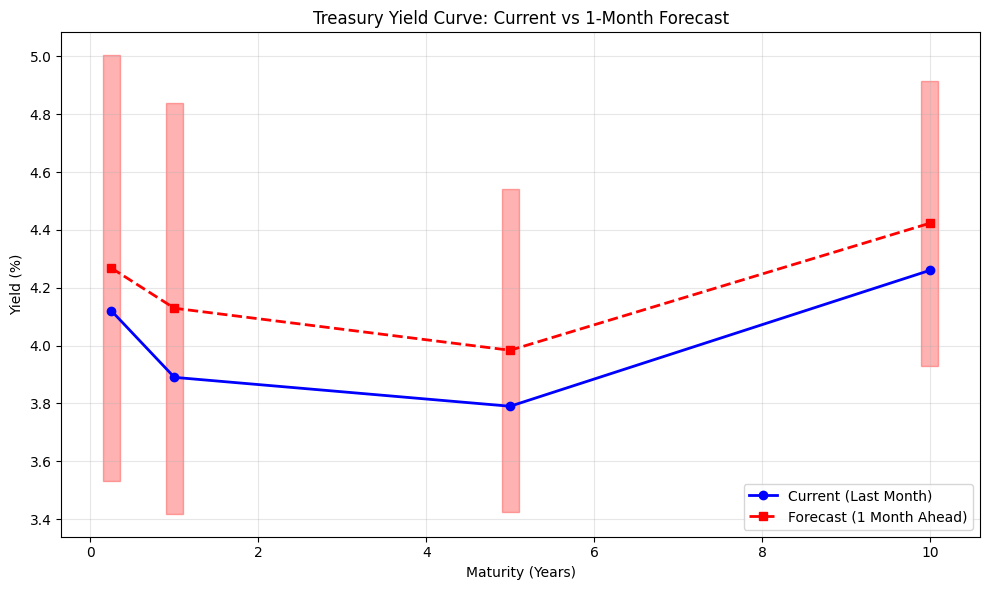


=== Forecast Summary ===
Last observation date: 2025-08
Forecast date: 2025-09

Forecasted Yields:
TB3MS: 4.268% (95% CI: [3.532, 5.004])
GS1: 4.129% (95% CI: [3.418, 4.840])
GS5: 3.984% (95% CI: [3.425, 4.542])
GS10: 4.423% (95% CI: [3.930, 4.916])

Expected Changes:
TB3MS: +0.148%
GS1: +0.239%
GS5: +0.194%
GS10: +0.163%

=== Model Diagnostics for GS10 ===
                               SARIMAX Results                                
Dep. Variable:                   GS10   No. Observations:                  799
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 -31.372
Date:                Tue, 25 Nov 2025   AIC                             72.745
Time:                        21:08:49   BIC                             96.155
Sample:                             0   HQIC                            81.739
                                - 799                                         
Covariance Type:                  opg                                         
       

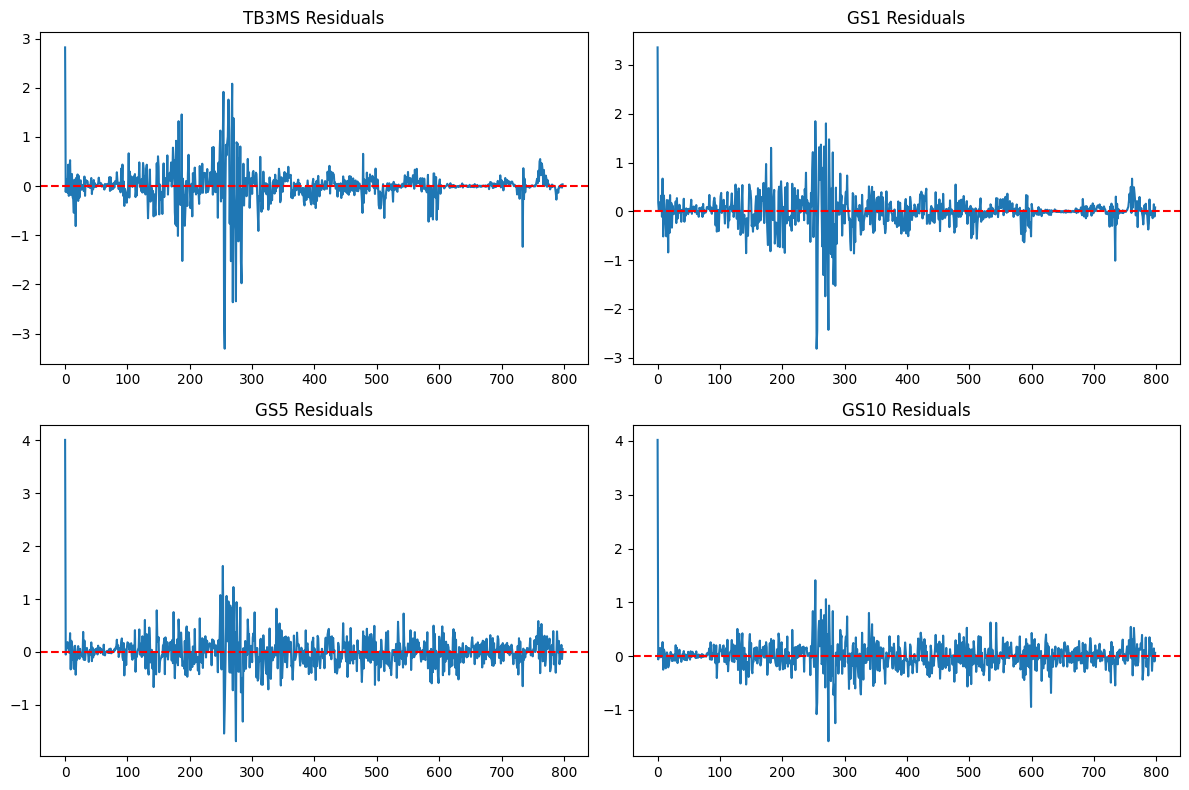

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load and prepare data (assuming your df is already loaded)
yield_columns = ['TB3MS', 'GS1', 'GS5', 'GS10']
maturities = [0.25, 1, 5, 10]  # in years

# Convert PeriodIndex to DatetimeIndex if needed
if isinstance(df.index, pd.PeriodIndex):
    df = df.copy()
    df.index = df.index.to_timestamp()

# Dictionary to store models and forecasts
models = {}
forecasts = {}
forecast_conf_intervals = {}

# Fit ARIMA models for each maturity
for col in yield_columns:
    print(f"Fitting ARIMA model for {col}...")
    
    # Get the series and drop NaN values
    y = df[col].dropna()
    
    # Split into train/test (keep last month for validation)
    train = y[:-1]
    test = y[-1:]
    
    # Fit ARIMA model
    # You can adjust (p,d,q) parameters - here using (2,1,2) as a starting point
    model = ARIMA(train, order=(2, 1, 2))
    fitted_model = model.fit()
    
    # Store the fitted model
    models[col] = fitted_model
    
    # Forecast 1 month ahead
    forecast_result = fitted_model.forecast(steps=1)
    forecasts[col] = forecast_result.iloc[0] if isinstance(forecast_result, pd.Series) else forecast_result[0]
    
    # Get confidence intervals
    forecast_obj = fitted_model.get_forecast(steps=1)
    conf_int = forecast_obj.conf_int()
    forecast_conf_intervals[col] = conf_int
    
    print(f"{col}: Forecast = {forecasts[col]:.3f}")

# Create the forecasted yield curve
forecast_yields = [forecasts[col] for col in yield_columns]

# Plot the current vs forecasted yield curve
fig, ax = plt.subplots(figsize=(10, 6))

# Current yield curve (last observation)
current_yields = [df[col].iloc[-1] for col in yield_columns]
ax.plot(maturities, current_yields, marker='o', linewidth=2, label='Current (Last Month)', color='blue')

# Forecasted yield curve
ax.plot(maturities, forecast_yields, marker='s', linewidth=2, label='Forecast (1 Month Ahead)', 
        color='red', linestyle='--')

# Add confidence intervals for each point
for i, col in enumerate(yield_columns):
    conf_int = forecast_conf_intervals[col]
    lower = conf_int.iloc[0, 0]
    upper = conf_int.iloc[0, 1]
    ax.fill_between([maturities[i]-0.1, maturities[i]+0.1], [lower, lower], [upper, upper], 
                     alpha=0.3, color='red')

ax.set_xlabel('Maturity (Years)')
ax.set_ylabel('Yield (%)')
ax.set_title('Treasury Yield Curve: Current vs 1-Month Forecast')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print forecast details
print("\n=== Forecast Summary ===")
print(f"Last observation date: {df['sasdate'].iloc[-1]}")
print(f"Forecast date: {df['sasdate'].iloc[-1] + 1}")
print("\nForecasted Yields:")
for col, forecast_val in zip(yield_columns, forecast_yields):
    conf_int = forecast_conf_intervals[col]
    print(f"{col}: {forecast_val:.3f}% (95% CI: [{conf_int.iloc[0,0]:.3f}, {conf_int.iloc[0,1]:.3f}])")

# Calculate changes from current
print("\nExpected Changes:")
for col, current, forecast in zip(yield_columns, current_yields, forecast_yields):
    change = forecast - current
    print(f"{col}: {change:+.3f}%")

# Optional: Model diagnostics for one of the series (e.g., GS10)
print(f"\n=== Model Diagnostics for GS10 ===")
print(models['GS10'].summary())

# Optional: Plot residuals
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for i, col in enumerate(yield_columns):
    residuals = models[col].resid
    axes[i].plot(residuals)
    axes[i].set_title(f'{col} Residuals')
    axes[i].axhline(y=0, color='r', linestyle='--')
plt.tight_layout()
plt.show()

In [177]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(yield_columns):
    series = df[col]
    plot_acf(series, ax=axes[i], title=f'{col} ACF Plot')
    axes[i].axhline(y=0, color='r', linestyle='--')

plt.tight_layout()
plt.show()

In [179]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(yield_columns):
    series = df[col]
    plot_pacf(series, ax=axes[i], title=f'{col} PACF Plot')
    axes[i].axhline(y=0, color='r', linestyle='--')

plt.tight_layout()
plt.show()

In [181]:
import requests, pprint, pandas as pd

fields = 'comp_tendered,comp_bid_decimals,comp_accepted,max_comp_award'
date_b = "1979-11-15"
date_e = "2025-11-25"

api_url = f'https://api.fiscaldata.treasury.gov/services/api/fiscal_service/v1/accounting/od/auctions_query?' \
f'field={fields}&' \
f'filter=record_date:gte:{date_b},record_date:lte:{date_e} &' \
'page[size]=100000'

response = requests.get(api_url)

# Check the status code (200 indicates success)
print(f"Status Code: {response.status_code}")

if response.status_code == 200:
    data = response.json()
    
    # The actual data is typically in data['data']
    a_df = pd.DataFrame(data['data'])
    
    print(f"Shape: {a_df.shape}")
    print(f"\nColumns: {a_df.columns.tolist()}")
    # print(f"\nFirst few rows:")
    # print(a_df.head())
    print(f"\nNull counts:")
    print(a_df.isnull().sum())
else:
    print(f"Error: {response.text}")


In [60]:
a_df

,record_date,cusip,security_type,security_term,auction_date,issue_date,maturity_date,price_per100,accrued_int_per100,accrued_int_per1000,...,total_tendered,treas_retail_accepted,treas_retail_tenders_accepted,unadj_accrued_int_per1000,unadj_price,xml_filenm_announcemt,xml_filenm_comp_results,inflation_index_security,tint_cusip_1,tint_cusip_2
0,1979-11-15,912827KC5,Note,10-Year,1979-10-31,1979-11-15,1989-11-15,null,null,0.0000000000,...,3818000000,null,null,null,null,null,null,No,null,null
1,1979-11-15,912810CK2,Bond,30-Year,1979-11-01,1979-11-15,2009-11-15,null,null,0.0000000000,...,3594000000,null,null,null,null,null,null,No,null,null
2,1980-01-03,9127933Y0,Bill,13-Week,1979-12-28,1980-01-03,1980-04-03,null,null,null,...,5371540000,null,null,null,null,null,null,No,null,null
3,1980-01-03,9127934U7,Bill,26-Week,1979-12-28,1980-01-03,1980-07-03,null,null,null,...,5954350000,null,null,null,null,null,null,No,null,null
4,1980-01-08,9127935W2,Bill,52-Week,1980-01-02,1980-01-08,1981-01-02,null,null,null,...,6329685000,null,null,null,null,null,null,No,null,null
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10749,2025-11-20,912797RA7,Bill,6-Week,2025-11-18,2025-11-20,2026-01-02,99.540139,null,null,...,270331654000,884214200,Yes,null,null,A_20251113_1.xml,R_20251118_1.xml,No,null,null
10750,2025-11-20,912797SV0,Bill,26-Week,2025-11-17,2025-11-20,2026-05-21,98.124389,null,null,...,219678657300,666364100,Yes,null,null,A_20251113_4.xml,R_20251117_2.xml,No,null,null
10751,2025-11-25,912797RY5,Bill,4-Week,2025-11-20,2025-11-25,2025-12-23,99.697444,null,null,...,302780538100,5255850800,Yes,null,null,A_20251118_1.xml,R_20251120_1.xml,No,null,null
10752,2025-11-25,912797SG3,Bill,8-Week,2025-11-20,2025-11-25,2026-01-20,99.401111,null,null,...,251130308900,898846300,Yes,null,null,A_20251118_3.xml,R_20251120_2.xml,No,null,null


In [61]:
a_df = a_df.replace("null", pd.NA)

cols_with_na = a_df.columns[a_df.isna().sum() > 10000].tolist()
cols_with_file = a_df.columns[a_df.columns.str.contains('file')].tolist()
noncomp = a_df.columns[a_df.columns.str.contains('noncomp')].tolist()

a_df = a_df.drop(
    cols_with_na+cols_with_file+noncomp, axis=1
)

a_df

,record_date,cusip,security_type,security_term,auction_date,issue_date,maturity_date,price_per100,accrued_int_per1000,allocation_pctage,...,soma_holdings,soma_included,soma_tendered,std_int_payment_per1000,strippable,total_accepted,total_tendered,treas_retail_accepted,treas_retail_tenders_accepted,inflation_index_security
0,1979-11-15,912827KC5,Note,10-Year,1979-10-31,1979-11-15,1989-11-15,<NA>,0.0000000000,99.000000,...,<NA>,<NA>,<NA>,53.7500,<NA>,2401000000,3818000000,<NA>,<NA>,No
1,1979-11-15,912810CK2,Bond,30-Year,1979-11-01,1979-11-15,2009-11-15,<NA>,0.0000000000,44.000000,...,<NA>,<NA>,<NA>,51.8750,<NA>,2315000000,3594000000,<NA>,<NA>,No
2,1980-01-03,9127933Y0,Bill,13-Week,1979-12-28,1980-01-03,1980-04-03,<NA>,<NA>,21.000000,...,<NA>,<NA>,<NA>,<NA>,<NA>,3257440000,5371540000,<NA>,<NA>,No
3,1980-01-03,9127934U7,Bill,26-Week,1979-12-28,1980-01-03,1980-07-03,<NA>,<NA>,94.000000,...,<NA>,<NA>,<NA>,<NA>,<NA>,3348725000,5954350000,<NA>,<NA>,No
4,1980-01-08,9127935W2,Bill,52-Week,1980-01-02,1980-01-08,1981-01-02,<NA>,<NA>,3.000000,...,<NA>,<NA>,<NA>,<NA>,<NA>,4007825000,6329685000,<NA>,<NA>,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10749,2025-11-20,912797RA7,Bill,6-Week,2025-11-18,2025-11-20,2026-01-02,99.540139,<NA>,36.420000,...,12527000000,No,4612677800,<NA>,<NA>,99612721600,270331654000,884214200,Yes,No
10750,2025-11-20,912797SV0,Bill,26-Week,2025-11-17,2025-11-20,2026-05-21,98.124389,<NA>,62.590000,...,12527000000,No,3738696700,<NA>,<NA>,80738808300,219678657300,666364100,Yes,No
10751,2025-11-25,912797RY5,Bill,4-Week,2025-11-20,2025-11-25,2025-12-23,99.697444,<NA>,35.200000,...,735000000,No,295043400,<NA>,<NA>,110295826100,302780538100,5255850800,Yes,No
10752,2025-11-25,912797SG3,Bill,8-Week,2025-11-20,2025-11-25,2026-01-20,99.401111,<NA>,33.830000,...,735000000,No,254810100,<NA>,<NA>,95254893900,251130308900,898846300,Yes,No


In [183]:
# a_df.columns.tolist()

In [63]:
import pandas as pd
import re

def parse_maturity_term(term_str):
    """
    Parse terms like '9-Year 10-Month' or '70-Day' and return total years
    """
    if pd.isna(term_str):
        return None
    
    term = str(term_str)
    years = 0
    months = 0
    days = 0
    
    # Extract years
    year_match = re.search(r'(\d+)-Year', term)
    if year_match:
        years = int(year_match.group(1))
    
    # Extract months
    month_match = re.search(r'(\d+)-Month', term)
    if month_match:
        months = int(month_match.group(1))
    
    # Extract days
    day_match = re.search(r'(\d+)-Day', term)
    if day_match:
        days = int(day_match.group(1))
    
    # Extract weeks
    week_match = re.search(r'(\d+)-Week', term)
    if week_match:
        days = int(week_match.group(1)) * 7
    
    # Convert to total years
    total_years = years + (months / 12) + (days / 365.25)
    return total_years

# Apply to your dataframe
a_df['years_to_maturity'] = a_df['security_term'].apply(parse_maturity_term)

# Now classify based on parsed years
def classify_maturity(years):
    if pd.isna(years):
        return 'unknown'
    elif years < 1:
        return 'bills'      # < 1 year (Bills)
    elif years < 3:
        return 'short'      # 1-3 years (treat as 2Y)
    elif years <= 7:
        return 'medium'     # 3-7 years (treat as 5Y or 7Y)
    else:
        return 'long'       # 7+ years (treat as 10Y+)

a_df['maturity_bucket'] = a_df['years_to_maturity'].apply(classify_maturity)
print(a_df['maturity_bucket'].value_counts())

maturity_bucket
bills     8062
medium    1086
long       912
short      694
Name: count, dtype: int64


In [64]:
a_df.groupby('maturity_bucket').count()

,record_date,cusip,security_type,security_term,auction_date,issue_date,maturity_date,price_per100,accrued_int_per1000,allocation_pctage,...,soma_included,soma_tendered,std_int_payment_per1000,strippable,total_accepted,total_tendered,treas_retail_accepted,treas_retail_tenders_accepted,inflation_index_security,years_to_maturity
maturity_bucket,,,,,,,,,,,,,,,,,,,,,
bills,8062,8062,8062,8062,8062,8062,8062,5701,0,8061,...,4215,4215,0,0,8061,8061,4214,4215,8062,8062
long,912,912,912,912,912,912,912,745,629,912,...,626,626,768,626,912,912,626,626,912,912
medium,1086,1086,1086,1086,1086,1086,1086,851,589,1086,...,678,678,1028,678,1086,1086,678,678,1086,1086
short,694,694,694,694,694,694,694,542,402,694,...,355,355,550,355,694,694,355,355,694,694


In [65]:
a_df['record_date'].dtype

dtype('O')

In [66]:
numeric_cols = [
    'bid_to_cover_ratio',    
    'offering_amt',          
    'total_accepted',         
    'total_tendered', 
    'comp_accepted',         
    'comp_tendered',          
    'primary_dealer_accepted',
    'primary_dealer_tendered', 
    'indirect_bidder_accepted', 
    'indirect_bidder_tendered',
    'direct_bidder_accepted',  
    'direct_bidder_tendered',]

a_df[numeric_cols] = a_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Check for any conversion issues
print("Null counts after conversion:")
print(a_df[numeric_cols].isnull().sum())

# Check data types
print("\nData types:")
print(a_df[numeric_cols].dtypes)

Null counts after conversion:
bid_to_cover_ratio          3215
offering_amt                   0
total_accepted                 1
total_tendered                 1
comp_accepted               4880
comp_tendered               4880
primary_dealer_accepted     4880
primary_dealer_tendered     4880
indirect_bidder_accepted    4880
indirect_bidder_tendered    4880
direct_bidder_accepted      4880
direct_bidder_tendered      4880
dtype: int64

Data types:
bid_to_cover_ratio          float64
offering_amt                  int64
total_accepted              float64
total_tendered              float64
comp_accepted               float64
comp_tendered               float64
primary_dealer_accepted     float64
primary_dealer_tendered     float64
indirect_bidder_accepted    float64
indirect_bidder_tendered    float64
direct_bidder_accepted      float64
direct_bidder_tendered      float64
dtype: object


In [67]:
# a_df['record_date'] = pd.to_datetime(a_df['record_date']).dt.to_timestamp()

In [68]:
a_df['record_date'] = pd.to_datetime(a_df['record_date']).dt.to_period('M')
# dff = a_df.groupby(['maturity_bucket', 'record_date'])[numeric_cols].mean().reset_index()
agg_df = a_df.groupby(['maturity_bucket', 'record_date'])[numeric_cols].agg('mean')


In [69]:
#dff = dff.rename_axis(['maturity_bucket', 'record_date'])

# move maturity_bucket from index into columns
dff_wide = agg_df.unstack('maturity_bucket')  # index: record_date
# columns are now a MultiIndex: (metric, maturity_bucket)

# flatten column names: years_to_maturity_bills, ...
dff_wide.columns = [
    f"{metric}_{bucket}" for metric, bucket in dff_wide.columns
]
dff_wide

,bid_to_cover_ratio_bills,bid_to_cover_ratio_long,bid_to_cover_ratio_medium,bid_to_cover_ratio_short,offering_amt_bills,offering_amt_long,offering_amt_medium,offering_amt_short,total_accepted_bills,total_accepted_long,...,indirect_bidder_tendered_medium,indirect_bidder_tendered_short,direct_bidder_accepted_bills,direct_bidder_accepted_long,direct_bidder_accepted_medium,direct_bidder_accepted_short,direct_bidder_tendered_bills,direct_bidder_tendered_long,direct_bidder_tendered_medium,direct_bidder_tendered_short
record_date,,,,,,,,,,,,,,,,,,,,,
1979-11,NaN,NaN,NaN,NaN,NaN,2.000000e+09,NaN,NaN,NaN,2.358000e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01,NaN,NaN,NaN,NaN,3.272727e+09,1.500000e+09,NaN,4.000000e+09,3.306578e+09,1.501000e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-02,NaN,NaN,NaN,NaN,3.311111e+09,2.000000e+09,3.250000e+09,4.000000e+09,3.311852e+09,2.548000e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-03,NaN,NaN,NaN,NaN,3.690909e+09,NaN,2.500000e+09,3.500000e+09,3.773676e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-04,NaN,NaN,NaN,NaN,3.716667e+09,1.500000e+09,NaN,4.000000e+09,3.723095e+09,1.501000e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07,2.994848,2.547500,2.536667,2.715000,6.978788e+10,2.375000e+10,5.733333e+10,4.950000e+10,7.172683e+10,2.613326e+10,...,4.273391e+10,3.825995e+10,4.376766e+09,6.184339e+09,1.746450e+10,1.188703e+10,1.006841e+10,8.982350e+09,2.423013e+10,1.630650e+10
2025-08,2.913200,2.466667,2.530000,3.220000,8.020000e+10,2.500000e+10,5.800000e+10,2.800000e+10,8.247798e+10,3.257939e+10,...,4.095304e+10,3.131000e+10,4.700642e+09,5.317933e+09,1.627514e+10,2.000000e+08,1.097601e+10,7.825267e+09,2.104300e+10,1.700000e+09
2025-09,2.915714,2.502000,2.464000,2.783333,8.071429e+10,2.180000e+10,5.720000e+10,5.533333e+10,8.192252e+10,2.253962e+10,...,4.441374e+10,4.456683e+10,5.035299e+09,4.761686e+09,1.420524e+10,1.468476e+10,1.122879e+10,7.292100e+09,1.968810e+10,2.088100e+10


In [185]:
# dff_wide.columns.tolist()

In [187]:
import seaborn as sns 

corr = dff_wide.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

Explained variance ratio: [0.78540527 0.06573605 0.04553529 0.02684175 0.01500102]
Cumulative variance: [0.78540527 0.85114132 0.89667661 0.92351836 0.93851937]


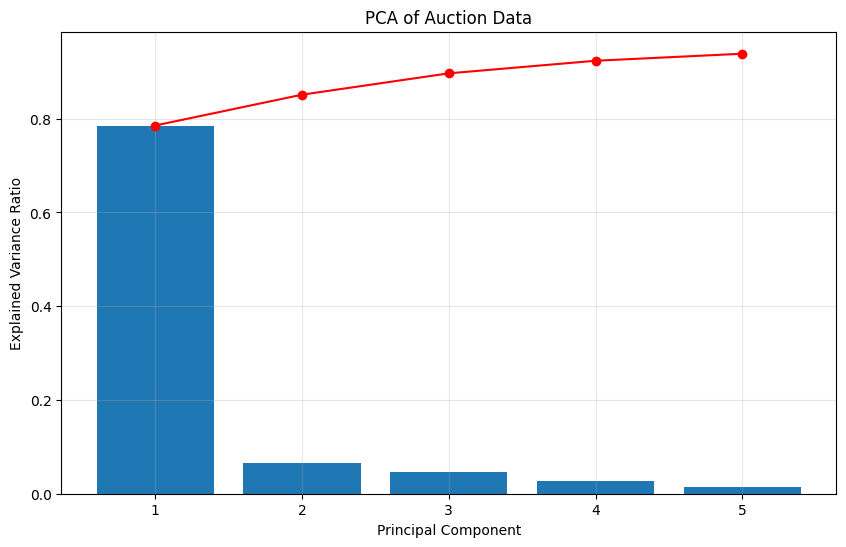

In [85]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


auction_data = dff_wide.fillna(0)

# Standardize
scaler = StandardScaler()
auction_scaled = scaler.fit_transform(auction_data)

# Apply PCA
pca = PCA(n_components=5)  # Keep top 10 components
auction_pca = pca.fit_transform(auction_scaled)

# Create PCA features
df_pca = pd.DataFrame(
    auction_pca,
    index=dff_wide.index,
    columns=[f'auction_pc_{i+1}' for i in range(5)]
)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative variance: {pca.explained_variance_ratio_.cumsum()}")

# Plot explained variance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(1, 6), pca.explained_variance_ratio_)
ax.plot(range(1, 6), pca.explained_variance_ratio_.cumsum(), 'ro-')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA of Auction Data')
ax.grid(True, alpha=0.3)
plt.show()

In [127]:
dff_wide

,auction_pc_1,auction_pc_2,auction_pc_3,auction_pc_4,auction_pc_5
record_date,,,,,
1979-11,1.110568,0.094376,-0.900189,-0.475798,0.109637
1980-01,1.082737,0.221673,-0.717842,-0.475091,0.153444
1980-02,1.035475,0.064510,-0.643799,-0.372163,0.244604
1980-03,1.127163,0.231908,-0.749727,-0.553802,0.128541
1980-04,1.081305,0.228133,-0.704709,-0.472602,0.151350
...,...,...,...,...,...
2025-07,-0.210900,-2.802616,2.699800,-2.565517,1.120533
2025-08,0.327402,-2.057175,2.465951,-0.915422,-2.329653
2025-09,0.001281,-1.568394,3.150943,-3.345195,0.789186


In [139]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Original data
auction_data = dff_wide.fillna(0)

original_columns = dff_wide.columns.tolist()

# Standardize
scaler = StandardScaler()
auction_scaled = scaler.fit_transform(auction_data)

# Apply PCA
pca = PCA(n_components=5)
auction_pca = pca.fit_transform(auction_scaled)

# Create reduced DataFrame with just 5 PCA features
dff_wide = pd.DataFrame(
    auction_pca,
    index=dff_wide.index,
    columns=[f'auction_pc_{i+1}' for i in range(5)]
)

pca_loadings = pd.DataFrame(
    pca.components_.T,  # Transpose so original features are rows
    columns=[f'PC{i+1}' for i in range(5)],
    index=original_columns  # ← Your original 48 column names
)

print("="*80)
print("PCA LOADINGS - Shows which original features contribute to each PC")
print("="*80)
print(pca_loadings)

# Now you can append to other features
# For example, if you have your FRED-MD data:
# Concatenate and drop rows with any NaN
df_combined = pd.concat([df, dff_wide], axis=1)
print(df_combined.iloc[10:14, :])
print(f"Before dropna: {df_combined.shape}")

# Drop rows where ANY auction PC is null
df_combined = df_combined.dropna(subset=[
    'auction_pc_1', 'auction_pc_2', 'auction_pc_3', 
    'auction_pc_4', 'auction_pc_5'
])

# Method 1: Inner join (only keeps matching dates)
df_combinedd = pd.merge(
    df,
    dff_wide,
    left_on = 'sasdate',
    right_on='record_date',
    how='right'  # Only keeps rows that exist in BOTH dataframes
)

print(f"After dropna: {df_combined.shape}")
print(f"Date range: {df_combined.index[0]} to {df_combined.index[-1]}")

print(f"\nCombined shape: {df_combined.shape}")
print(f"Combined columns: {df_combined.columns.tolist()}")

NameError: name 'original_columns' is not defined

In [145]:
df_combinedd

,sasdate,FEDFUNDS,CPIAUCSL,INDPRO,UNRATE,M2SL,S&P 500,TB3MS,GS1,GS5,GS10,auction_pc_1,auction_pc_2,auction_pc_3,auction_pc_4,auction_pc_5
0,1979-11,13.18,76.000,51.6341,5.9,1465.9,103.70,11.79,12.39,10.93,10.65,0.328862,1.021451,0.648897,-0.580456,-0.617660
1,1980-01,13.82,78.000,51.9440,6.3,1482.7,110.90,12.00,12.06,10.74,10.80,0.265405,1.036011,0.531989,-0.608472,-0.434745
2,1980-02,14.13,79.000,51.9633,6.3,1494.6,115.30,12.86,13.92,12.60,12.41,0.302625,0.830358,0.589868,-0.644703,-0.380160
3,1980-03,17.19,80.100,51.7454,6.3,1499.8,104.70,15.20,15.82,13.47,12.75,0.237690,1.100830,0.529370,-0.645346,-0.494532
4,1980-04,17.61,80.900,50.7197,6.9,1502.2,103.00,13.20,13.30,11.84,11.47,0.264579,1.034934,0.520551,-0.609408,-0.425085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,2025-07,4.33,322.132,103.8194,4.2,22115.8,6296.50,4.25,4.08,3.95,4.39,-2.510495,-2.508598,-0.453482,-3.170468,-0.415167
548,2025-08,4.33,323.364,103.9203,4.3,22195.4,6408.95,4.12,3.89,3.79,4.26,-0.131853,-1.846845,-2.855117,-1.635778,-1.558741
549,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.107431,-1.377651,-1.305286,-3.307059,-0.083591
550,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.486026,-1.084907,-2.014598,-2.763130,-0.338239


In [91]:
auction_data.isna().sum()

bid_to_cover_ratio_bills           0
bid_to_cover_ratio_long            0
bid_to_cover_ratio_medium          0
bid_to_cover_ratio_short           0
offering_amt_bills                 0
offering_amt_long                  0
offering_amt_medium                0
offering_amt_short                 0
total_accepted_bills               0
total_accepted_long                0
total_accepted_medium              0
total_accepted_short               0
total_tendered_bills               0
total_tendered_long                0
total_tendered_medium              0
total_tendered_short               0
comp_accepted_bills                0
comp_accepted_long                 0
comp_accepted_medium               0
comp_accepted_short                0
comp_tendered_bills                0
comp_tendered_long                 0
comp_tendered_medium               0
comp_tendered_short                0
primary_dealer_accepted_bills      0
primary_dealer_accepted_long       0
primary_dealer_accepted_medium     0
p

In [93]:
df_combined = df_combined.ffill()

In [95]:
df_combined.isna().sum()

sasdate         552
FEDFUNDS        552
CPIAUCSL        552
INDPRO          552
UNRATE          552
M2SL            552
S&P 500         552
TB3MS           552
GS1             552
GS5             552
GS10            552
auction_pc_1      0
auction_pc_2      0
auction_pc_3      0
auction_pc_4      0
auction_pc_5      0
dtype: int64

In [149]:
df_combinedd = df_combinedd.iloc[:-3]

In [165]:
df_combinedd

,sasdate,FEDFUNDS,CPIAUCSL,INDPRO,UNRATE,M2SL,S&P 500,TB3MS,GS1,GS5,GS10,auction_pc_1,auction_pc_2,auction_pc_3,auction_pc_4,auction_pc_5
0,1979-11,13.18,76.000,51.6341,5.9,1465.9,103.70,11.79,12.39,10.93,10.65,0.328862,1.021451,0.648897,-0.580456,-0.617660
1,1980-01,13.82,78.000,51.9440,6.3,1482.7,110.90,12.00,12.06,10.74,10.80,0.265405,1.036011,0.531989,-0.608472,-0.434745
2,1980-02,14.13,79.000,51.9633,6.3,1494.6,115.30,12.86,13.92,12.60,12.41,0.302625,0.830358,0.589868,-0.644703,-0.380160
3,1980-03,17.19,80.100,51.7454,6.3,1499.8,104.70,15.20,15.82,13.47,12.75,0.237690,1.100830,0.529370,-0.645346,-0.494532
4,1980-04,17.61,80.900,50.7197,6.9,1502.2,103.00,13.20,13.30,11.84,11.47,0.264579,1.034934,0.520551,-0.609408,-0.425085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,2025-04,4.33,320.321,103.6224,4.2,21805.1,5369.50,4.21,3.95,3.91,4.28,-2.054802,-0.815677,-2.028755,-1.737492,0.123622
545,2025-05,4.33,320.580,103.6570,4.2,21884.6,5810.92,4.25,4.09,4.02,4.42,0.087420,-2.530679,-2.291524,-1.404497,-1.399251
546,2025-06,4.33,321.500,104.2115,4.1,22022.1,6029.95,4.23,4.06,3.96,4.38,-2.808955,-1.149062,-1.172364,-2.404199,0.453697
547,2025-07,4.33,322.132,103.8194,4.2,22115.8,6296.50,4.25,4.08,3.95,4.39,-2.510495,-2.508598,-0.453482,-3.170468,-0.415167


In [99]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [151]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

X = np.array(df_combinedd[[
    'FEDFUNDS',   # Current policy rate
    'CPIAUCSL',   # Inflation
    'INDPRO',     # Industrial production
    'UNRATE',     # Unemployment
    'M2SL',       # Money supply
    'S&P 500',    # Equity market
    'auction_pc_1',
    'auction_pc_2',
    'auction_pc_3',
    'auction_pc_4',
    'auction_pc_5',
]].ffill())

y = np.array(df_combinedd[['TB3MS', 'GS1', 'GS5', 'GS10']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(4)  # Regression output
])

# Compile
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Train
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"\nTest MAE: {test_mae:.4f}")
print(f"Test MSE: {test_loss:.4f}")

# Make predictions
predictions = model.predict(X_test_scaled)

Epoch 1/100


/opt/homebrew/anaconda3/envs/keras-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 52.7747 - mae: 6.5166 - val_loss: 3.4601 - val_mae: 1.4137
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 49.6779 - mae: 6.3025 - val_loss: 2.7176 - val_mae: 1.1845
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 45.3057 - mae: 5.9915 - val_loss: 2.4418 - val_mae: 1.1562
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 40.3334 - mae: 5.5794 - val_loss: 2.7776 - val_mae: 1.4440
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 32.5483 - mae: 4.8802 - val_loss: 4.3663 - val_mae: 1.9641
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25.0916 - mae: 4.0642 - val_loss: 7.3735 - val_mae: 2.5093
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.7449 - mae: 3.0852 - val_loss: 8.1399 - val_mae: 2.5313
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.8891 - mae: 2.5945 - val_loss: 5.9090 - val_mae: 2.1295
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.4385 - 

Predictions shape: (110, 4)

Latest prediction (4 yields): [7.2503176 7.7756305 8.513199  8.343552 ]
Latest actual (4 yields): [4.12 3.89 3.79 4.26]


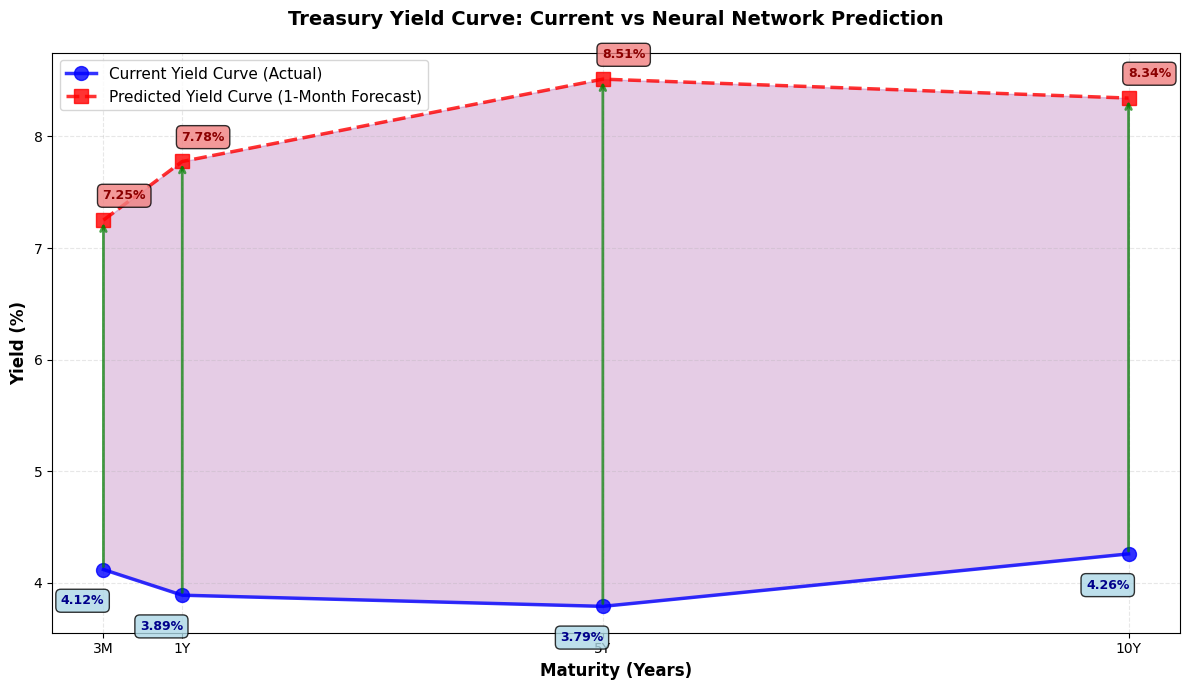


YIELD CURVE FORECAST - 1 MONTH AHEAD
Maturity     Current      Predicted    Change (bp)     % Change    
--------------------------------------------------------------------------------
TB3MS             4.120%      7.250% ↑    313.0 bp      75.98%
GS1               3.890%      7.776% ↑    388.6 bp      99.89%
GS5               3.790%      8.513% ↑    472.3 bp     124.62%
GS10              4.260%      8.344% ↑    408.4 bp      95.86%

Average change: +395.57 basis points

Curve Steepness (10Y - 3M):
  Current:   0.140%
  Predicted: 1.093%
  Change:    +95.3 bp

Model Performance on Test Set:
  MAE: 2.2839
  MSE: 6.4842
  RMSE: 2.5464


In [155]:
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on test set
# predictions = model.predict(X_test_scaled)

print(f"Predictions shape: {predictions.shape}")  # Should be (n_test_samples, 4)

# Get the LAST prediction (most recent forecast)
latest_prediction = predictions[-1]  # Last row = most recent
print(f"\nLatest prediction (4 yields): {latest_prediction}")

# Get the current (actual) yields
latest_actual = y_test[-1]  # Actual values for last month
print(f"Latest actual (4 yields): {latest_actual}")

# Define maturities and yield names
maturities = [0.25, 1, 5, 10]  # 3-month, 1-year, 5-year, 10-year
yield_names = ['TB3MS', 'GS1', 'GS5', 'GS10']

# ===== PLOT THE YIELD CURVE =====

fig, ax = plt.subplots(figsize=(12, 7))

# Current yield curve (actual)
ax.plot(maturities, latest_actual, 'o-', linewidth=2.5, markersize=10,
        label='Current Yield Curve (Actual)', color='blue', alpha=0.8)

# Predicted yield curve
ax.plot(maturities, latest_prediction, 's--', linewidth=2.5, markersize=10,
        label='Predicted Yield Curve (1-Month Forecast)', color='red', alpha=0.8)

# Fill between
ax.fill_between(maturities, latest_actual, latest_prediction, alpha=0.2, color='purple')

# Add value labels on points
for i, (mat, curr, pred, name) in enumerate(zip(maturities, latest_actual, latest_prediction, yield_names)):
    # Current value
    ax.annotate(f'{curr:.2f}%', 
                xy=(mat, curr), 
                xytext=(-15, -25), 
                textcoords='offset points',
                ha='center',
                fontsize=9,
                color='darkblue',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.8))
    
    # Predicted value
    ax.annotate(f'{pred:.2f}%', 
                xy=(mat, pred), 
                xytext=(15, 15), 
                textcoords='offset points',
                ha='center',
                fontsize=9,
                color='darkred',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightcoral', alpha=0.8))
    
    # Change arrow
    change = pred - curr
    if abs(change) > 0.05:  # Only show arrow if change > 5 basis points
        arrow_color = 'green' if change > 0 else 'red'
        ax.annotate('', 
                   xy=(mat, pred), 
                   xytext=(mat, curr),
                   arrowprops=dict(arrowstyle='->', color=arrow_color, lw=2, alpha=0.7))

ax.set_xlabel('Maturity (Years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Yield (%)', fontsize=12, fontweight='bold')
ax.set_title('Treasury Yield Curve: Current vs Neural Network Prediction', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(maturities)
ax.set_xticklabels(['3M', '1Y', '5Y', '10Y'])

plt.tight_layout()
plt.show()

# ===== PRINT DETAILED COMPARISON =====

print("\n" + "="*80)
print("YIELD CURVE FORECAST - 1 MONTH AHEAD")
print("="*80)
print(f"{'Maturity':<12} {'Current':<12} {'Predicted':<12} {'Change (bp)':<15} {'% Change':<12}")
print("-"*80)

for mat, name, curr, pred in zip(maturities, yield_names, latest_actual, latest_prediction):
    change_bp = (pred - curr) * 100  # Convert to basis points
    pct_change = ((pred - curr) / curr) * 100 if curr != 0 else 0
    change_symbol = '↑' if change_bp > 0 else '↓' if change_bp < 0 else '→'
    
    print(f"{name:<12} {curr:>10.3f}% {pred:>10.3f}% {change_symbol} {abs(change_bp):>8.1f} bp {pct_change:>10.2f}%")

print("="*80)

# Summary statistics
avg_change_bp = np.mean(latest_prediction - latest_actual) * 100
print(f"\nAverage change: {avg_change_bp:+.2f} basis points")

# Curve steepness
current_steepness = latest_actual[3] - latest_actual[0]  # 10Y - 3M
predicted_steepness = latest_prediction[3] - latest_prediction[0]

print(f"\nCurve Steepness (10Y - 3M):")
print(f"  Current:   {current_steepness:.3f}%")
print(f"  Predicted: {predicted_steepness:.3f}%")
print(f"  Change:    {(predicted_steepness - current_steepness)*100:+.1f} bp")

# Model performance on test set
print(f"\nModel Performance on Test Set:")
print(f"  MAE: {test_mae:.4f}")
print(f"  MSE: {test_loss:.4f}")
print(f"  RMSE: {np.sqrt(test_loss):.4f}")

In [169]:
# 1. Check if there's data leakage or scaling issues
print("Data Quality Check:")
print(f"X_train range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"X_test range: [{X_test.min():.2f}, {X_test.max():.2f}]")
print(f"y_train range: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"y_test range: [{y_test.min():.2f}, {y_test.max():.2f}]")

# 2. Check train/test split dates
print(f"\nTrain period: {df_combinedd['sasdate'].iloc[0]} to {df_combinedd.index[-1]}")
print(f"Test period: {df_combinedd[0]} to {df_combinedd.index[-1]}")

# 3. Check model predictions on training data
train_predictions = model.predict(X_train_scaled)
train_mae = mean_absolute_error(y_train, train_predictions)
print(f"\nTrain MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Overfitting ratio: {test_mae/train_mae:.2f}x")

# 4. Look at prediction distribution
print(f"\nPrediction stats:")
print(f"  Min: {predictions.min():.2f}")
print(f"  Max: {predictions.max():.2f}")
print(f"  Mean: {predictions.mean():.2f}")
print(f"  Actual test mean: {y_test.mean():.2f}")

Data Quality Check:
X_train range: [-3.07, 12835.40]
X_test range: [-3.72, 22195.40]
y_train range: [0.01, 16.72]
y_test range: [0.02, 5.44]

Train period: 1979-11 to 548


KeyError: 0